<a href="https://colab.research.google.com/github/Maanvijangir/Github-demo/blob/main/crop_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mounting dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Extract data from zip file

In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip -d /content/drive/MyDrive/unzipped_data

unzip:  cannot find or open /content/drive/MyDrive/archive.zip/test, /content/drive/MyDrive/archive.zip/test.zip or /content/drive/MyDrive/archive.zip/test.ZIP.


Extracting specific dir from file

In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip "test/*" -d /content/drive/MyDrive/unzipped_data

Verifying dataset in available on drive or not


In [ ]:
!ls /content/drive/MyDrive/'New Plant Diseases Dataset(Augmented)'
!ls /content/drive/MyDrive/unzipped_data/'New Plant Diseases Dataset(Augmented)'/'New Plant Diseases Dataset(Augmented)'


'New Plant Diseases Dataset(Augmented)'
train  valid


Verifying dataset

In [ ]:


!ls /content/drive/MyDrive/unzipped_data/test | wc -l
!ls /content/drive/MyDrive/unzipped_data/'New Plant Diseases Dataset(Augmented)'/'New Plant Diseases Dataset(Augmented)'/valid | wc -l
!ls /content/drive/MyDrive/unzipped_data/'New Plant Diseases Dataset(Augmented)'/'New Plant Diseases Dataset(Augmented)'/train | head


1
38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy


In [ ]:
!rm -rf /content/drive/MyDrive/unzipped_data/'new plant diseases dataset(augmented)'


In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip "new plant diseases dataset(augmented)/*" -d /content/drive/MyDrive/unzipped_data

In [1]:
!cp /content/drive/MyDrive/archive.zip /content/dataset.zip
!unzip -q /content/dataset.zip -d /content/unzipped_data
!rm /content/dataset.zip

Finally starting the process

# **Importing Libraries**

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# **Data Preprocessing**

Training img Preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 70295 files belonging to 38 classes.


Validation Img Preprocessing

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 70295 files belonging to 38 classes.


In [ ]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [ ]:
for x,y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[147.   178.    98.  ]
   [136.25 167.25  87.25]
   [128.75 159.75  81.75]
   ...
   [211.   227.   190.  ]
   [205.25 221.25 185.25]
   [203.   219.   183.  ]]

  [[154.5  186.5  103.5 ]
   [141.   172.    92.  ]
   [131.75 162.75  82.75]
   ...
   [208.25 224.25 187.25]
   [202.75 218.75 182.75]
   [204.5  220.5  184.5 ]]

  [[157.   189.   104.  ]
   [142.5  174.5   91.5 ]
   [136.5  167.5   87.5 ]
   ...
   [208.75 224.75 188.75]
   [198.75 214.75 178.75]
   [203.25 218.25 185.25]]

  ...

  [[ 49.    79.25  52.  ]
   [ 35.75  70.75  34.5 ]
   [ 51.5   90.25  41.25]
   ...
   [176.25 204.25 154.75]
   [172.5  202.5  149.  ]
   [177.5  208.25 152.  ]]

  [[ 27.75  57.    35.  ]
   [ 24.25  58.25  27.75]
   [ 53.75  92.25  46.25]
   ...
   [178.   206.   157.25]
   [173.5  203.5  151.  ]
   [177.75 207.75 153.75]]

  [[ 29.75  58.75  39.75]
   [ 28.75  62.25  34.25]
   [ 47.    84.5   42.  ]
   ...
   [178.   206.   157.5 ]
   [173.   203.   151.5 ]
   [176.75 206.75 15

In [45]:
for _,y in training_set.take(1):
  print("Labels shape:", y.shape)
  print("First labels:", y[:5].numpy())


Labels shape: (32, 38)
First labels: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [47]:
def normalize_images(image, label):
    image = tf.cast(image, tf.float32) / 255.0   # scale to [0,1]
    return image, label

training_set = training_set.map(normalize_images)
validation_set = validation_set.map(normalize_images)


In [48]:
for x, y in training_set.take(1):
    print("Images batch shape:", x.shape)
    print("Labels batch shape:", y.shape)
    print("First 5 labels:", y[:5].numpy())


Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32, 38)
First 5 labels: [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


# **Building Model**

In [5]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential

In [6]:
model = Sequential()

Simple Dense NueralNnetwork(MLP)

In [49]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(38,activation='softmax')
])

Recurrent Nueral Network is not used bcoz data is not sequential

building convolutional layer

In [7]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [9]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [11]:
model.add(Flatten())

In [12]:
model.add(Dense(units=1024,activation='relu')) #dense layer is basically our hidden layer & units are the number of nueron we want

In [13]:
model.add(Dense(units=38,activation='softmax')) #output layer

Compiling model

In [50]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [52]:
model2.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001, clipnorm=1.0),loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989,446 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [39]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [21]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 190s 81ms/step - accuracy: 0.5703 - loss: 1.6042 - val_accuracy: 0.9203 - val_loss: 0.2656
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9151 - loss: 0.2721 - val_accuracy: 0.9713 - val_loss: 0.0974
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 164s 75ms/step - accuracy: 0.9533 - loss: 0.1423 - val_accuracy: 0.9780 - val_loss: 0.0649
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 204s 76ms/step - accuracy: 0.9695 - loss: 0.0921 - val_accuracy: 0.9888 - val_loss: 0.0359
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9793 - loss: 0.0585 - val_accuracy: 0.9846 - val_loss: 0.0460
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9826 - loss: 0.0547 - val_accuracy: 0.9864 - val_loss: 0.0397
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 202s 92ms/step - accuracy: 0.9869 - loss: 0.0402 - val_accuracy: 0.9838 - val_loss: 0.0483
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 201s 92ms/step - accuracy: 

In [53]:
training_history2 = model2.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 99s 44ms/step - accuracy: 0.0808 - loss: 3.5241 - val_accuracy: 0.1157 - val_loss: 3.2800
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 95s 43ms/step - accuracy: 0.1180 - loss: 3.2306 - val_accuracy: 0.1467 - val_loss: 3.0990
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 97s 44ms/step - accuracy: 0.1518 - loss: 3.0560 - val_accuracy: 0.1734 - val_loss: 2.9233
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - accuracy: 0.1857 - loss: 2.8906 - val_accuracy: 0.2046 - val_loss: 2.7847
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 96s 43ms/step - accuracy: 0.2114 - loss: 2.7653 - val_accuracy: 0.2277 - val_loss: 2.6836
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.2437 - loss: 2.6540 - val_accuracy: 0.2781 - val_loss: 2.5498
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 118s 54ms/step - accuracy: 0.2888 - loss: 2.5210 - val_accuracy: 0.2985 - val_loss: 2.4818
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.31

Plotting the data to compare

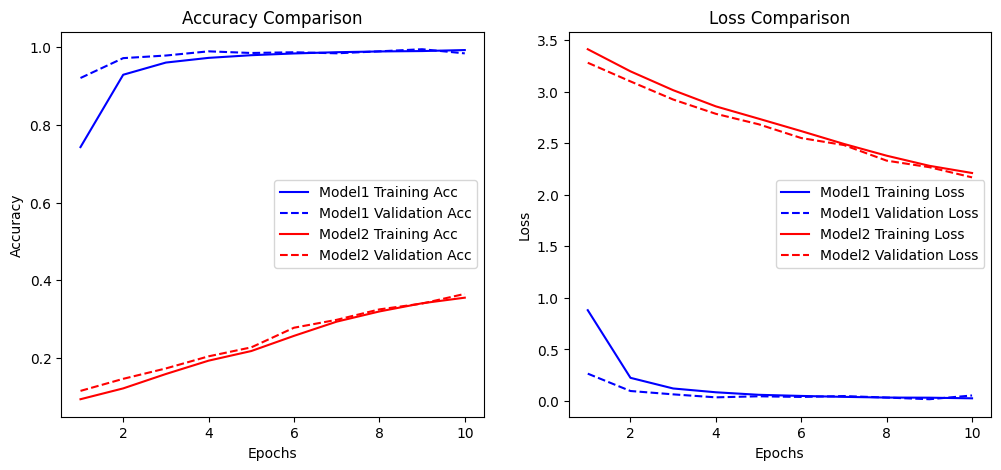

In [55]:

acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

acc2 = training_history2.history['accuracy']
val_acc2 = training_history2.history['val_accuracy']
loss2 = training_history2.history['loss']
val_loss2 = training_history2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Model1 Training Acc')
plt.plot(epochs, val_acc, 'b--', label='Model1 Validation Acc')
plt.plot(epochs, acc2, 'r-', label='Model2 Training Acc')
plt.plot(epochs, val_acc2, 'r--', label='Model2 Validation Acc')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Model1 Training Loss')
plt.plot(epochs, val_loss, 'b--', label='Model1 Validation Loss')
plt.plot(epochs, loss2, 'r-', label='Model2 Training Loss')
plt.plot(epochs, val_loss2, 'r--', label='Model2 Validation Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

